##  Setup, imports, output folder (EEE combined-DAG notebook

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import io

from sklearn.preprocessing import LabelEncoder

import dowhy
from dowhy import CausalModel

from econml.dml import CausalForestDML
from econml.cate_interpreter import SingleTreePolicyInterpreter

import warnings
warnings.filterwarnings('ignore')

# Output folder for this module
output_dir = r"C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE"
os.makedirs(output_dir, exist_ok=True)

print("Output directory ready:", output_dir)
print("dowhy version:", dowhy.__version__)

Output directory ready: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE
dowhy version: 0.14


## Block 2 — Raw load and preprocessing for EEE

In [5]:
# Block 2 — Raw load, imd_band fix, encodings, assessment/click NaN handling + binning

raw_path = r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\EEE.csv"
df = pd.read_csv(raw_path)

print("Raw shape:", df.shape)
print(df.columns.tolist())

Raw shape: (2934, 32)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'clicks_dualpane', 'clicks_forumng', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_page', 'clicks_quiz', 'clicks_resource', 'clicks_subpage', 'clicks_url']


## Block 2b — Encoding, imd_band fix, assessment/click preprocessing

In [8]:
# Block 2b — Encoding maps, imd_band bug fix, assessment NaN->-1 + quartile bin, click NaN->0

# imd_band bug fix
df['imd_band'] = df['imd_band'].replace('10-20', '10-20%')
df['imd_band'] = df['imd_band'].fillna(df['imd_band'].mode()[0])

# Locked encoding maps
final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
highest_education_map = {
    'No Formal quals': 0, 'Lower Than A Level': 1, 'A Level or Equivalent': 2,
    'HE Qualification': 3, 'Post Graduate Qualification': 4
}
imd_band_map = {
    '0-10%': 0, '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
age_band_map = {'0-35': 0, '35-55': 1, '55<=': 2}
gender_map = {'F': 0, 'M': 1}
disability_map = {'N': 0, 'Y': 1}

df['final_result'] = df['final_result'].map(final_result_map)
df['highest_education'] = df['highest_education'].map(highest_education_map)
df['imd_band'] = df['imd_band'].map(imd_band_map)
df['age_band'] = df['age_band'].map(age_band_map)
df['gender'] = df['gender'].map(gender_map)
df['disability'] = df['disability'].map(disability_map)

le_region = LabelEncoder()
df['region'] = le_region.fit_transform(df['region'])

# Assessment columns: NaN -> -1, then quartile bin
assessment_cols = ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score']
for col in assessment_cols:
    df[col] = df[col].fillna(-1)
    df[col + '_binned'] = pd.qcut(df[col], q=4, labels=False, duplicates='drop')

# Click columns: NaN -> 0
click_cols = ['clicks_dualpane', 'clicks_forumng', 'clicks_homepage', 'clicks_oucollaborate',
              'clicks_oucontent', 'clicks_ouwiki', 'clicks_page', 'clicks_quiz',
              'clicks_resource', 'clicks_subpage', 'clicks_url']
for col in click_cols:
    df[col] = df[col].fillna(0)

print("Preprocessing done.")
print(df[['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'final_result']].head())
print("\nAssessment bin counts:")
for col in assessment_cols:
    print(col, df[col + '_binned'].value_counts().sort_index().to_dict())

Preprocessing done.
   gender  region  highest_education  imd_band  age_band  final_result
0       1      10                  1         0         1             1
1       1       5                  2         6         0             0
2       1      10                  1         0         1             2
3       1      11                  2         4         1             0
4       1       6                  3         9         1             2

Assessment bin counts:
ass_1_score {0: 736, 1: 763, 2: 750, 3: 685}
ass_2_score {0: 1484, 1: 740, 2: 710}
ass_3_score {0: 1478, 1: 725, 2: 731}
ass_4_score {0: 1476, 1: 752, 2: 706}


## Block 3 — Click variation check before summing into total_clicks

In [11]:
# Block 3 — Check nonzero count and unique values per click column before summing

click_variation = []
for col in click_cols:
    nonzero = (df[col] > 0).sum()
    unique_vals = df[col].nunique()
    click_variation.append({'column': col, 'nonzero_count': nonzero, 'nonzero_pct': round(nonzero/len(df)*100, 1), 'unique_values': unique_vals})

click_var_df = pd.DataFrame(click_variation)
print(click_var_df)

                  column  nonzero_count  nonzero_pct  unique_values
0        clicks_dualpane           1059         36.1             27
1         clicks_forumng           2452         83.6            811
2        clicks_homepage           2682         91.4            699
3   clicks_oucollaborate           1433         48.8             39
4       clicks_oucontent           2642         90.0           1207
5          clicks_ouwiki           1846         62.9            610
6            clicks_page            343         11.7             17
7            clicks_quiz           2527         86.1            279
8        clicks_resource           2234         76.1            136
9         clicks_subpage           2461         83.9            167
10            clicks_url           2448         83.4            183


## Block 4 — Build total_clicks, quartile bin, drop individual click columns

In [14]:
# Block 4 — Sum raw clicks into total_clicks, quartile bin, drop individual columns

df['total_clicks'] = df[click_cols].sum(axis=1)
df['total_clicks_binned'] = pd.qcut(df['total_clicks'], q=4, labels=False, duplicates='drop')

print("total_clicks summary:")
print(df['total_clicks'].describe())
print("\ntotal_clicks bin counts:")
print(df['total_clicks_binned'].value_counts().sort_index())

total_clicks summary:
count     2934.000000
mean      1357.950579
std       1381.879277
min          0.000000
25%        312.000000
50%       1072.500000
75%       1938.000000
max      13382.000000
Name: total_clicks, dtype: float64

total_clicks bin counts:
total_clicks_binned
0    735
1    732
2    734
3    733
Name: count, dtype: int64


## Block 5 — Drop date/ID columns, build final df_model

In [19]:
# Block 5 — Build df_model: keep encoded demographics, binned assessments, binned total_clicks, final_result

df_model = df[[
    'gender', 'region', 'highest_education', 'imd_band', 'age_band',
    'num_of_prev_attempts', 'studied_credits', 'disability',
    'ass_1_score_binned', 'ass_2_score_binned', 'ass_3_score_binned', 'ass_4_score_binned',
    'total_clicks_binned', 'final_result'
]].copy()

# Rename binned columns back to plain names for modeling convenience
df_model = df_model.rename(columns={
    'ass_1_score_binned': 'ass_1_score',
    'ass_2_score_binned': 'ass_2_score',
    'ass_3_score_binned': 'ass_3_score',
    'ass_4_score_binned': 'ass_4_score',
    'total_clicks_binned': 'total_clicks'
})

print("df_model shape:", df_model.shape)
print(df_model.dtypes)
print(df_model.head())

df_model shape: (2934, 14)
gender                  int64
region                  int64
highest_education       int64
imd_band                int64
age_band                int64
num_of_prev_attempts    int64
studied_credits         int64
disability              int64
ass_1_score             int64
ass_2_score             int64
ass_3_score             int64
ass_4_score             int64
total_clicks            int64
final_result            int64
dtype: object
   gender  region  highest_education  imd_band  age_band  \
0       1      10                  1         0         1   
1       1       5                  2         6         0   
2       1      10                  1         0         1   
3       1      11                  2         4         1   
4       1       6                  3         9         1   

   num_of_prev_attempts  studied_credits  disability  ass_1_score  \
0                     0               30           0            0   
1                     0               60

## Build EEE combined DAG in networkx, derive treatments and adjustment sets

In [22]:
# Block 6 — Build DiGraph from confirmed edge list, derive treatments (path to final_result) and adjustment sets

edges = [
    ('gender', 'studied_credits'),
    ('region', 'highest_education'),
    ('region', 'imd_band'),
    ('region', 'ass_2_score'),
    ('highest_education', 'imd_band'),
    ('age_band', 'highest_education'),
    ('age_band', 'total_clicks'),
    ('num_of_prev_attempts', 'total_clicks'),
    ('ass_1_score', 'ass_2_score'),
    ('ass_1_score', 'ass_3_score'),
    ('ass_1_score', 'ass_4_score'),
    ('ass_1_score', 'final_result'),
    ('total_clicks', 'ass_1_score'),
    ('ass_2_score', 'ass_3_score'),
    ('ass_2_score', 'ass_4_score'),
    ('total_clicks', 'ass_2_score'),
    ('ass_3_score', 'ass_4_score'),
    ('ass_3_score', 'final_result'),
    ('total_clicks', 'ass_3_score'),
    ('ass_4_score', 'final_result'),
    ('total_clicks', 'ass_4_score'),
    ('total_clicks', 'final_result'),
]

G = nx.DiGraph()
G.add_edges_from(edges)

treatments = [n for n in G.nodes() if n != 'final_result' and nx.has_path(G, n, 'final_result')]
print("Treatments:", treatments)

adjustment_sets = {t: list(G.predecessors(t)) for t in treatments}
for t, adj in adjustment_sets.items():
    print(t, "->", adj)

Treatments: ['region', 'ass_2_score', 'age_band', 'total_clicks', 'num_of_prev_attempts', 'ass_1_score', 'ass_3_score', 'ass_4_score']
region -> []
ass_2_score -> ['region', 'ass_1_score', 'total_clicks']
age_band -> []
total_clicks -> ['age_band', 'num_of_prev_attempts']
num_of_prev_attempts -> []
ass_1_score -> ['total_clicks']
ass_3_score -> ['ass_1_score', 'ass_2_score', 'total_clicks']
ass_4_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score', 'total_clicks']


## DoWhy ATE loop — all 8 treatments, with 95% confidence intervals

In [25]:
# Block 7 — DoWhy ATE loop, backdoor.linear_regression, 95% CI

results = []

for treatment in treatments:
    common_causes = adjustment_sets[treatment]

    model = CausalModel(
        data=df_model,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    results.append({
        'treatment': treatment, 'adjustment_set': common_causes,
        'ATE': ate, 'CI_lower': ci_low, 'CI_upper': ci_high, 'significant': significant
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

results_df = pd.DataFrame(results)
results_df

region: ATE=-0.002, CI=[-0.012, 0.008], significant=False
ass_2_score: ATE=0.241, CI=[0.204, 0.279], significant=True
age_band: ATE=0.091, CI=[0.010, 0.173], significant=True
total_clicks: ATE=0.667, CI=[0.646, 0.689], significant=True
num_of_prev_attempts: ATE=-0.268, CI=[-0.416, -0.119], significant=True
ass_1_score: ATE=0.255, CI=[0.228, 0.283], significant=True
ass_3_score: ATE=0.301, CI=[0.261, 0.342], significant=True
ass_4_score: ATE=0.335, CI=[0.295, 0.376], significant=True


,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,region,[],-0.002106,-0.012427,0.008216,False
1,ass_2_score,"[region, ass_1_score, total_clicks]",0.241172,0.203607,0.278736,True
2,age_band,[],0.091233,0.009954,0.172511,True
3,total_clicks,"[age_band, num_of_prev_attempts]",0.667115,0.645500,0.688730,True
4,num_of_prev_attempts,[],-0.267531,-0.416043,-0.119019,True
5,ass_1_score,[total_clicks],0.255414,0.227937,0.282890,True
6,ass_3_score,"[ass_1_score, ass_2_score, total_clicks]",0.301205,0.260781,0.341628,True
7,ass_4_score,"[ass_1_score, ass_2_score, ass_3_score, total_...",0.335305,0.294873,0.375737,True


## Refutation — placebo treatment + random common cause, all 8 treatments

In [28]:
# Block 8 — Refutation loop: placebo treatment + random common cause, one treatment at a time

refutation_results = []

for treatment in treatments:
    common_causes = adjustment_sets[treatment]

    model = CausalModel(
        data=df_model,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    original_ate = estimate.value

    placebo_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="placebo_treatment_refuter", placebo_type="permute"
    )
    random_cause_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="random_common_cause"
    )

    refutation_results.append({
        'treatment': treatment, 'original_ATE': original_ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'random_cause_new_effect': random_cause_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - original_ate)
    })

    print(f"{treatment}: placebo_effect={placebo_refute.new_effect:.4f}, random_cause_effect={random_cause_refute.new_effect:.4f}")

refutation_df = pd.DataFrame(refutation_results)
refutation_df

region: placebo_effect=-0.0002, random_cause_effect=-0.0021
ass_2_score: placebo_effect=0.0013, random_cause_effect=0.2412
age_band: placebo_effect=-0.0051, random_cause_effect=0.0912
total_clicks: placebo_effect=-0.0013, random_cause_effect=0.6671
num_of_prev_attempts: placebo_effect=-0.0052, random_cause_effect=-0.2676
ass_1_score: placebo_effect=-0.0010, random_cause_effect=0.2554
ass_3_score: placebo_effect=0.0018, random_cause_effect=0.3012
ass_4_score: placebo_effect=0.0001, random_cause_effect=0.3352


,treatment,original_ATE,placebo_new_effect,random_cause_new_effect,random_cause_diff
0,region,-0.002106,-0.000215,-0.002111,0.000006
1,ass_2_score,0.241172,0.001333,0.241224,0.000053
2,age_band,0.091233,-0.005098,0.091171,0.000061
3,total_clicks,0.667115,-0.001262,0.667090,0.000025
4,num_of_prev_attempts,-0.267531,-0.005181,-0.267628,0.000097
5,ass_1_score,0.255414,-0.000978,0.255418,0.000004
6,ass_3_score,0.301205,0.001768,0.301221,0.000017
7,ass_4_score,0.335305,0.000128,0.335241,0.000063


## EconML CausalForestDML — CATE setup, age_band vs imd_band moderators

In [31]:
# Block 9 — CATE loop, all 8 treatments x 2 moderators, skip when treatment==moderator

cate_results = []
moderators = ['age_band', 'imd_band']

for treatment in treatments:
    adj_set = adjustment_sets[treatment]

    for moderator in moderators:
        if treatment == moderator:
            continue

        W_cols = [c for c in adj_set if c != moderator]

        X = df_model[[moderator]].values
        T = df_model[treatment].values
        Y = df_model['final_result'].values
        W = df_model[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        cate_values = est.effect(X)

        cate_results.append({
            'treatment': treatment, 'moderator': moderator, 'W_cols': W_cols,
            'CATE_mean': cate_values.mean(), 'CATE_min': cate_values.min(),
            'CATE_max': cate_values.max(), 'CATE_std': cate_values.std()
        })

        print(f"{treatment} | moderator={moderator}: mean={cate_values.mean():.3f}, std={cate_values.std():.3f}")

cate_df = pd.DataFrame(cate_results)
cate_df

region | moderator=age_band: mean=-0.001, std=0.001
region | moderator=imd_band: mean=-0.001, std=0.014
ass_2_score | moderator=age_band: mean=0.243, std=0.019
ass_2_score | moderator=imd_band: mean=0.238, std=0.067
age_band | moderator=imd_band: mean=0.056, std=0.173
total_clicks | moderator=age_band: mean=0.667, std=0.004
total_clicks | moderator=imd_band: mean=0.660, std=0.021
num_of_prev_attempts | moderator=age_band: mean=-0.266, std=0.012
num_of_prev_attempts | moderator=imd_band: mean=-0.300, std=0.204
ass_1_score | moderator=age_band: mean=0.223, std=0.006
ass_1_score | moderator=imd_band: mean=0.221, std=0.055
ass_3_score | moderator=age_band: mean=0.299, std=0.027
ass_3_score | moderator=imd_band: mean=0.301, std=0.067
ass_4_score | moderator=age_band: mean=0.329, std=0.005
ass_4_score | moderator=imd_band: mean=0.327, std=0.054


,treatment,moderator,W_cols,CATE_mean,CATE_min,CATE_max,CATE_std
0,region,age_band,[],-0.000973,-0.002748,-0.000408,0.001002
1,region,imd_band,[],-0.001460,-0.026622,0.022527,0.013700
2,ass_2_score,age_band,"[region, ass_1_score, total_clicks]",0.242719,0.209206,0.253398,0.018918
3,ass_2_score,imd_band,"[region, ass_1_score, total_clicks]",0.237534,0.011631,0.297566,0.067254
4,age_band,imd_band,[],0.056037,-0.215414,0.370053,0.172749
5,total_clicks,age_band,[num_of_prev_attempts],0.667106,0.660753,0.669131,0.003586
6,total_clicks,imd_band,"[age_band, num_of_prev_attempts]",0.660364,0.622695,0.699347,0.021321
7,num_of_prev_attempts,age_band,[],-0.265981,-0.272825,-0.244505,0.012123
8,num_of_prev_attempts,imd_band,[],-0.299689,-0.538608,0.111283,0.203561
9,ass_1_score,age_band,[total_clicks],0.223209,0.211745,0.226862,0.006472


## CATE point + 95% CI plots by moderator bin — looped, saved per treatment

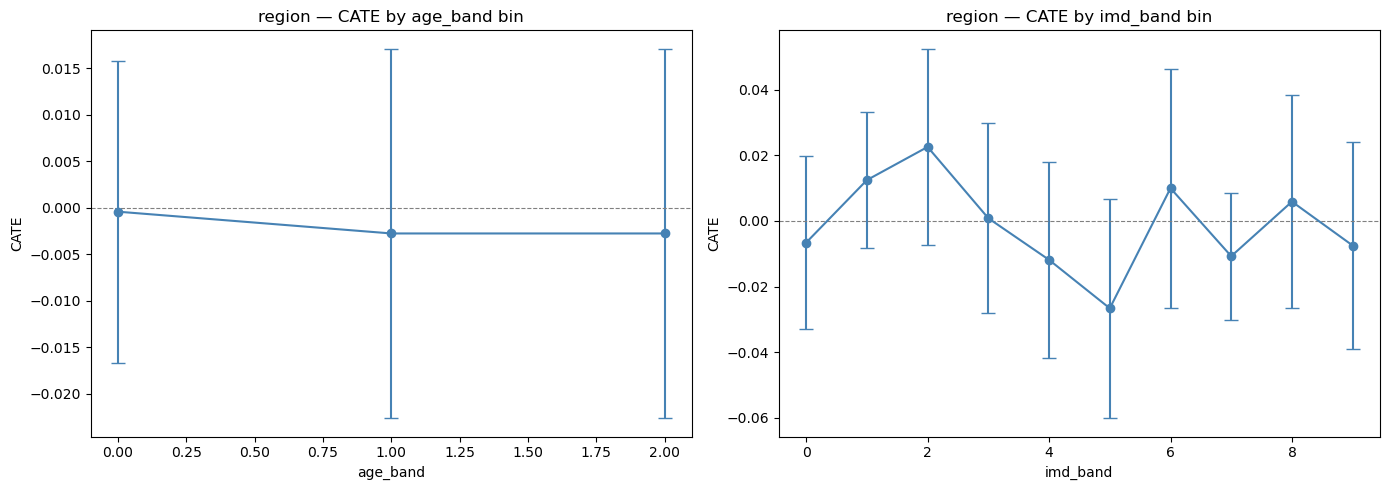

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE\EEE_CATE_region.png


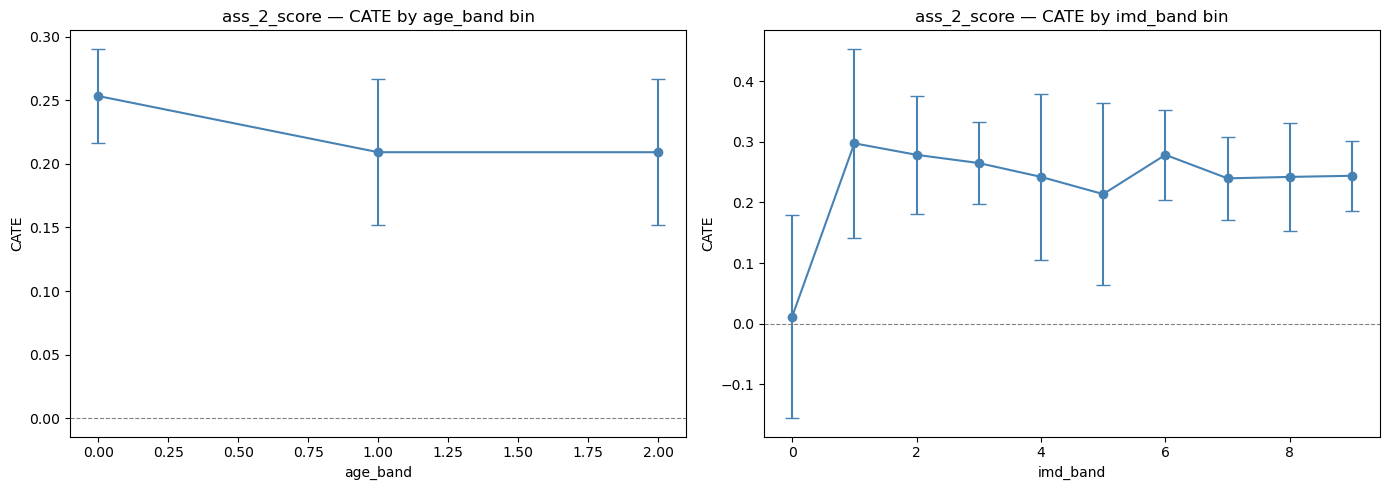

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE\EEE_CATE_ass_2_score.png


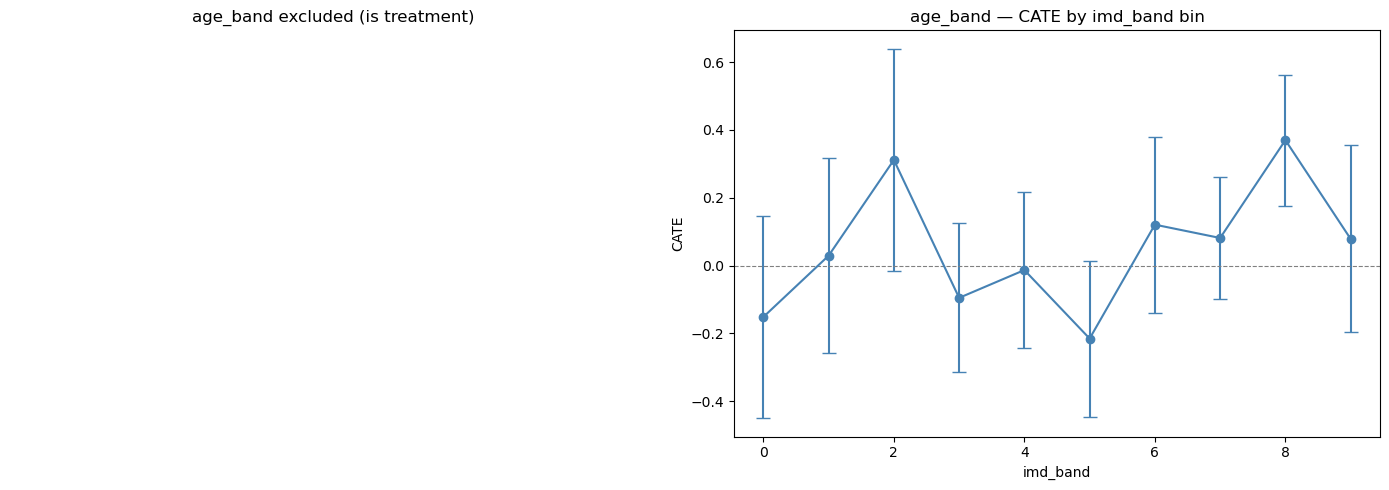

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE\EEE_CATE_age_band.png


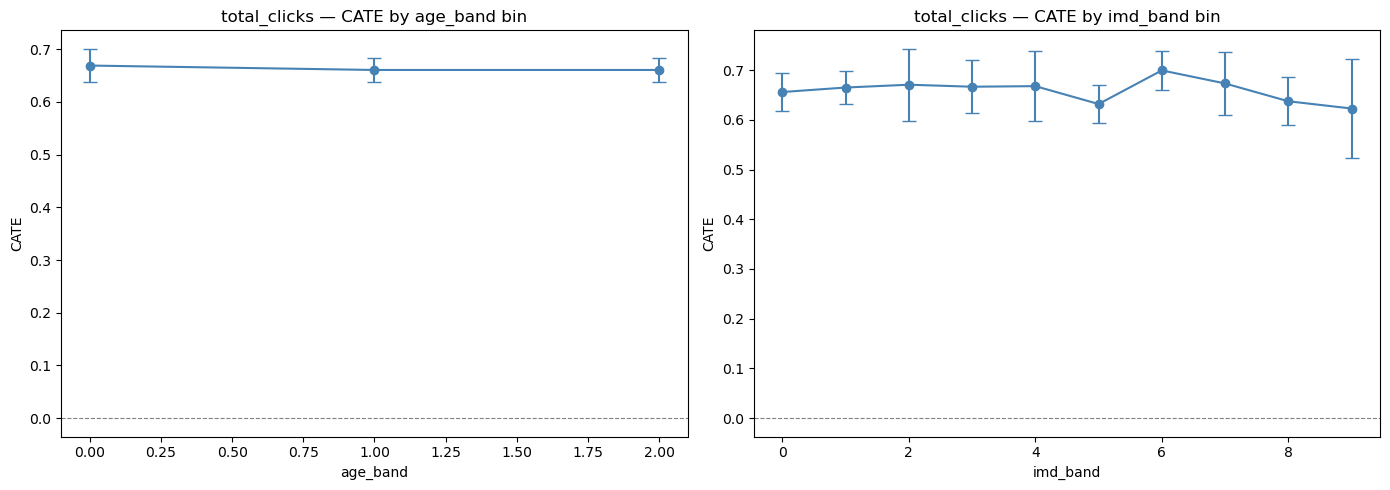

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE\EEE_CATE_total_clicks.png


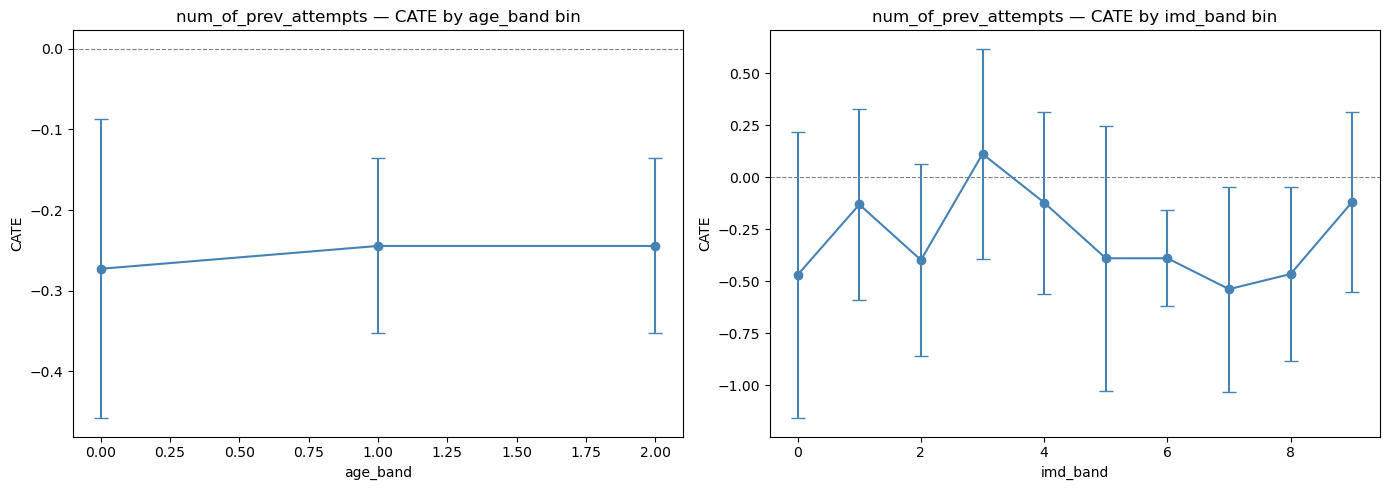

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE\EEE_CATE_num_of_prev_attempts.png


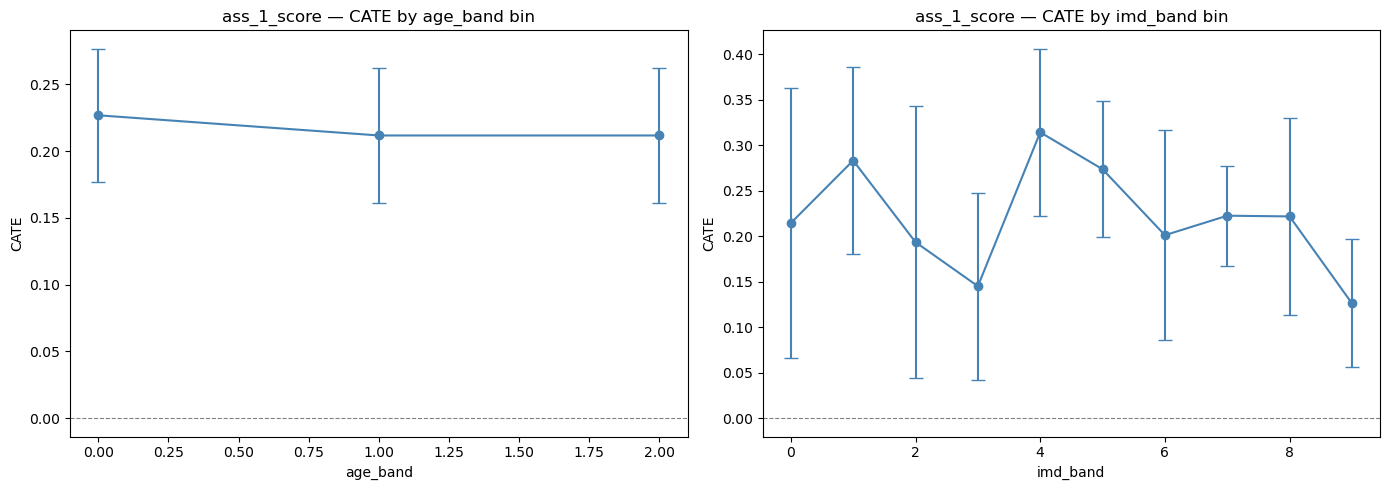

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE\EEE_CATE_ass_1_score.png


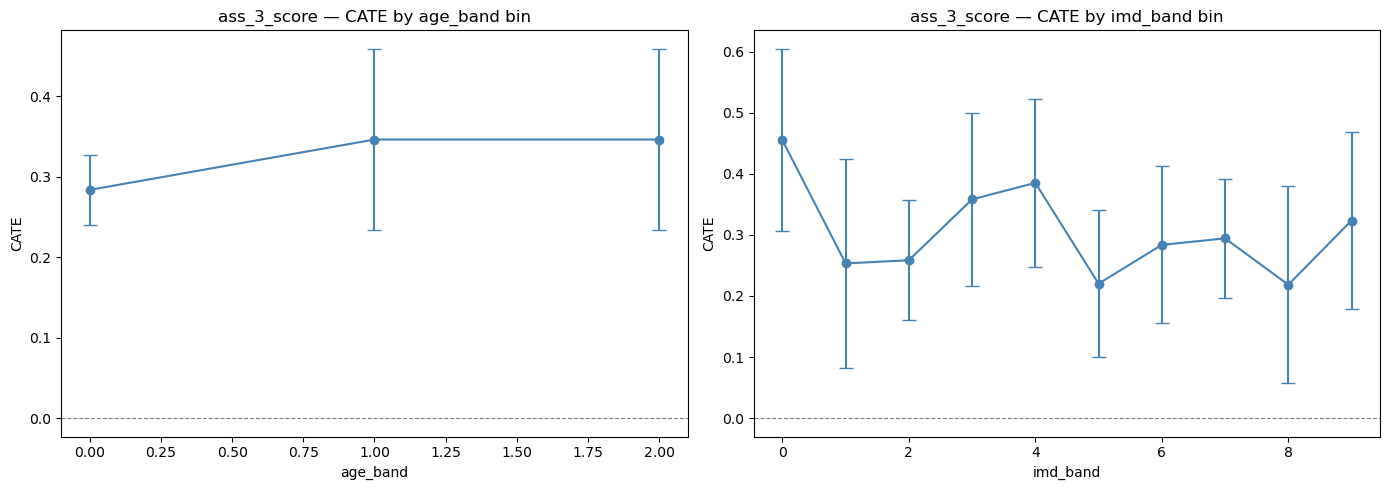

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE\EEE_CATE_ass_3_score.png


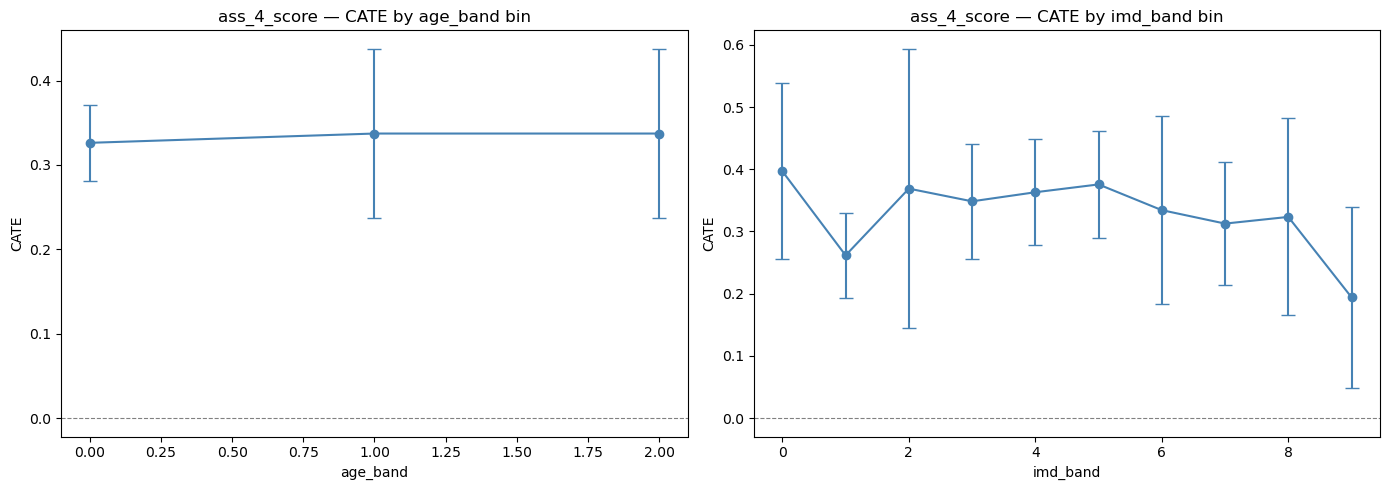

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE\EEE_CATE_ass_4_score.png


In [34]:
# Block 10 — CATE point + CI plots by moderator bin

for treatment in treatments:
    adj_set = adjustment_sets[treatment]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, moderator in zip(axes, moderators):
        if treatment == moderator:
            ax.axis('off')
            ax.set_title(f"{moderator} excluded (is treatment)")
            continue

        W_cols = [c for c in adj_set if c != moderator]

        X = df_model[[moderator]].values
        T = df_model[treatment].values
        Y = df_model['final_result'].values
        W = df_model[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        bin_values = sorted(df_model[moderator].unique())
        X_bins = np.array(bin_values).reshape(-1, 1)

        point_estimates = est.effect(X_bins)
        lb, ub = est.effect_interval(X_bins, alpha=0.05)
        yerr = np.array([point_estimates - lb, ub - point_estimates])

        ax.errorbar(bin_values, point_estimates, yerr=yerr, fmt='o-', capsize=5, color='steelblue')
        ax.set_xlabel(moderator)
        ax.set_ylabel('CATE')
        ax.set_title(f'{treatment} — CATE by {moderator} bin')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    save_path = os.path.join(output_dir, f"EEE_CATE_{treatment}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

## Policy tree — total_clicks only, both moderators, cost=0 (illustrative)

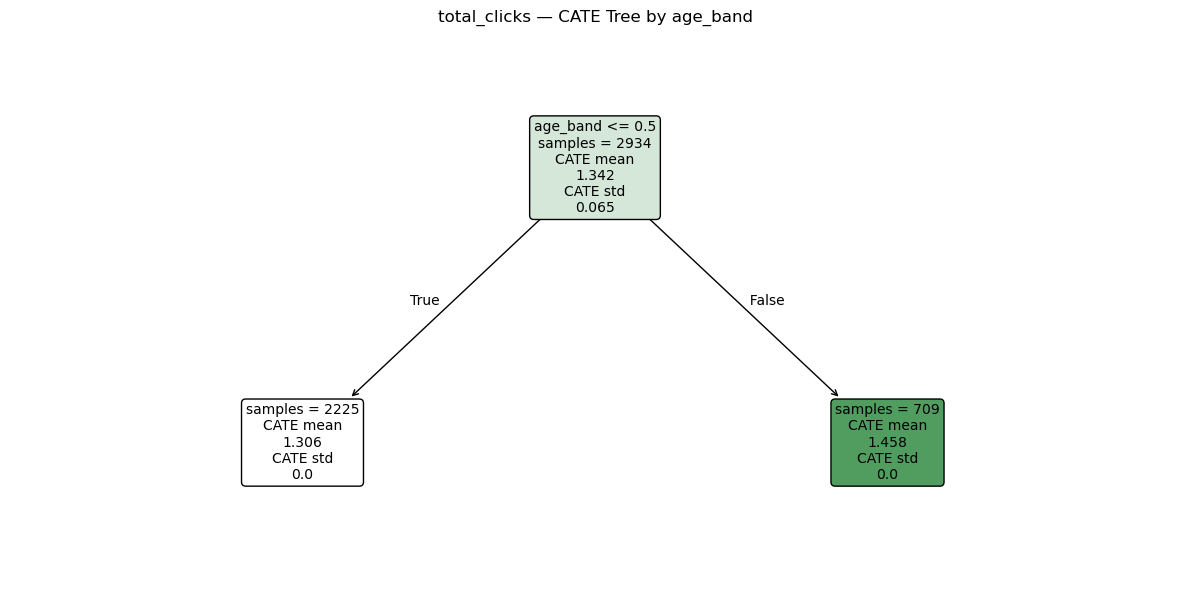

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE\EEE_CATEtree_total_clicks_age_band.png


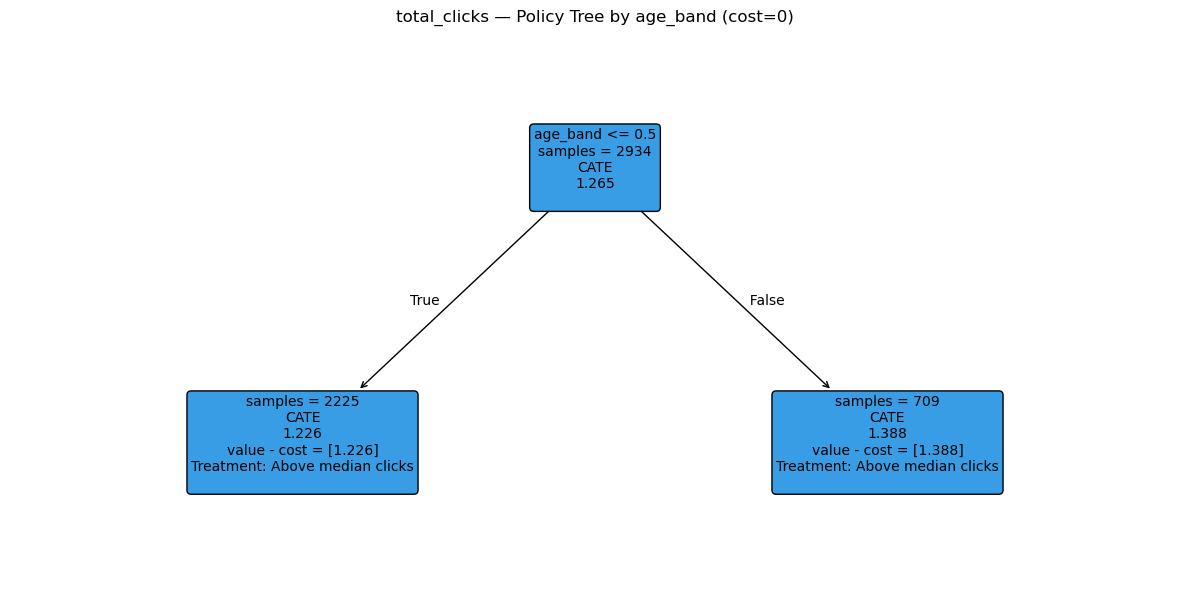

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE\EEE_policytree_total_clicks_age_band.png


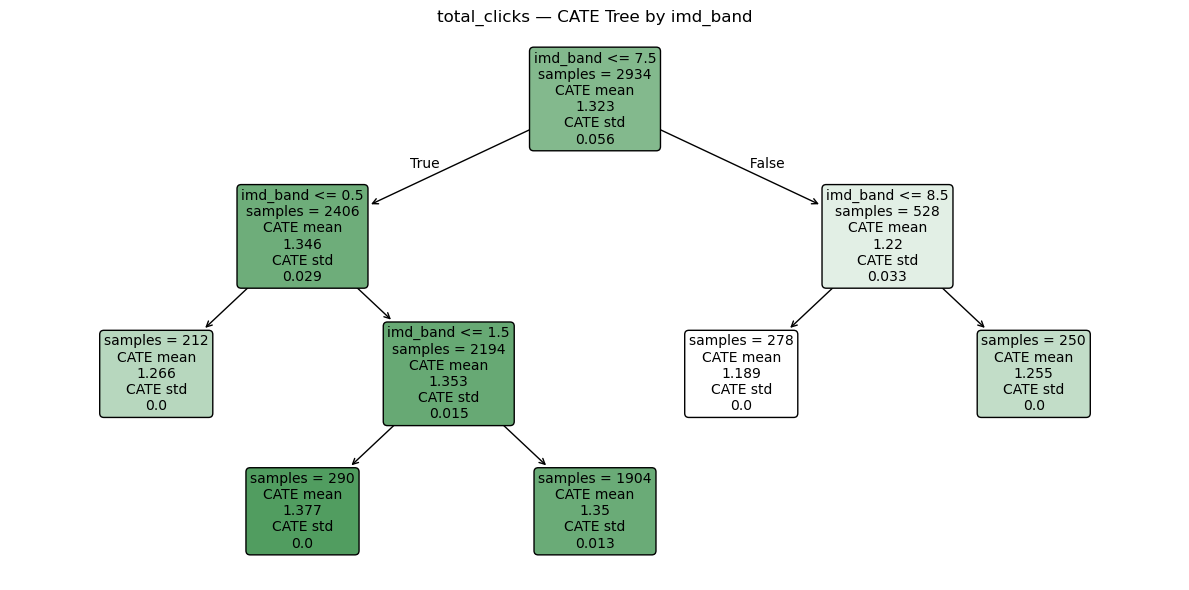

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE\EEE_CATEtree_total_clicks_imd_band.png


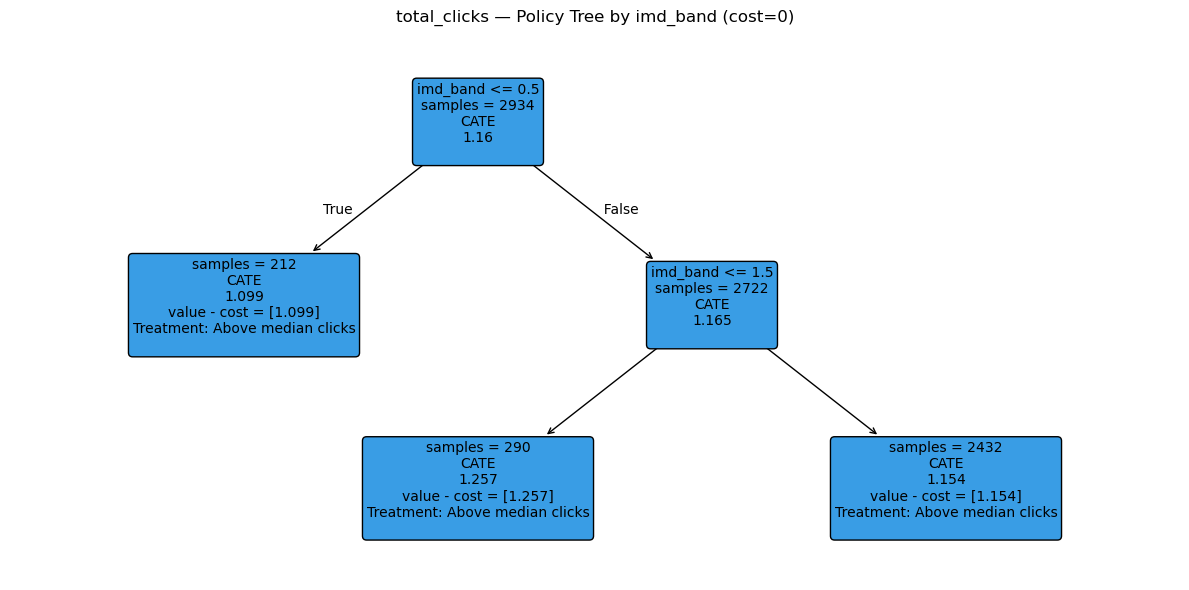

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE\EEE_policytree_total_clicks_imd_band.png


In [37]:
# Block 11 — Policy tree restricted to total_clicks, both moderators, cost=0

from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter

treatment = 'total_clicks'
adj_set = adjustment_sets[treatment]

for moderator in moderators:
    W_cols = [c for c in adj_set if c != moderator]

    X = df_model[[moderator]].values
    T_binary = (df_model[treatment] >= df_model[treatment].median()).astype(int).values
    Y = df_model['final_result'].values
    W = df_model[W_cols].values if len(W_cols) > 0 else None

    est = CausalForestDML(random_state=42)
    est.fit(Y, T_binary, X=X, W=W)

    cate_interpreter = SingleTreeCateInterpreter(include_model_uncertainty=False, max_depth=3)
    cate_interpreter.interpret(est, X)

    plt.figure(figsize=(12, 6))
    cate_interpreter.plot(feature_names=[moderator], fontsize=10)
    plt.title(f'total_clicks — CATE Tree by {moderator}')
    plt.tight_layout()
    save_path = os.path.join(output_dir, f"EEE_CATEtree_total_clicks_{moderator}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

    policy_interpreter = SingleTreePolicyInterpreter(risk_level=0.05, max_depth=3, min_samples_leaf=30)
    policy_interpreter.interpret(est, X, sample_treatment_costs=0)

    plt.figure(figsize=(12, 6))
    policy_interpreter.plot(feature_names=[moderator], treatment_names=['Below median clicks', 'Above median clicks'], fontsize=10)
    plt.title(f'total_clicks — Policy Tree by {moderator} (cost=0)')
    plt.tight_layout()
    save_path = os.path.join(output_dir, f"EEE_policytree_total_clicks_{moderator}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

## ATE heatmap

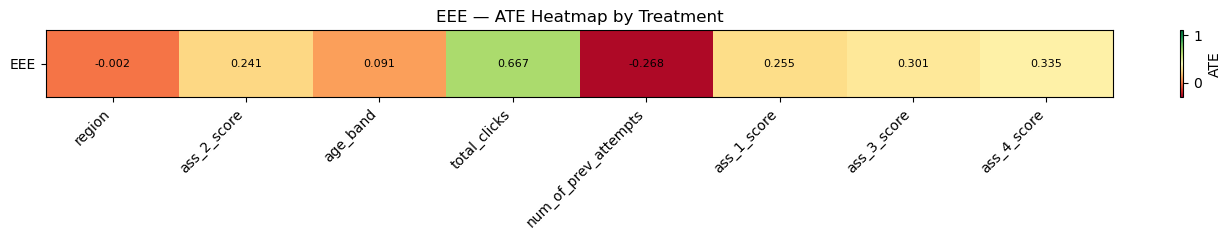

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE\EEE_ATE_heatmap.png


In [40]:
# Block 12 — ATE heatmap, single row for EEE

heatmap_data = results_df.set_index('treatment')[['ATE']].T

plt.figure(figsize=(14, 2.5))
plt.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-0.3, vmax=1.1)
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha='right')
plt.yticks([0], ['EEE'])
plt.colorbar(label='ATE')

for i, val in enumerate(heatmap_data.values[0]):
    plt.text(i, 0, f'{val:.3f}', ha='center', va='center', fontsize=8)

plt.title('EEE — ATE Heatmap by Treatment')
plt.tight_layout()
save_path = os.path.join(output_dir, "EEE_ATE_heatmap.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")

## DAG with ATE node overlay — manual fixed-position layout

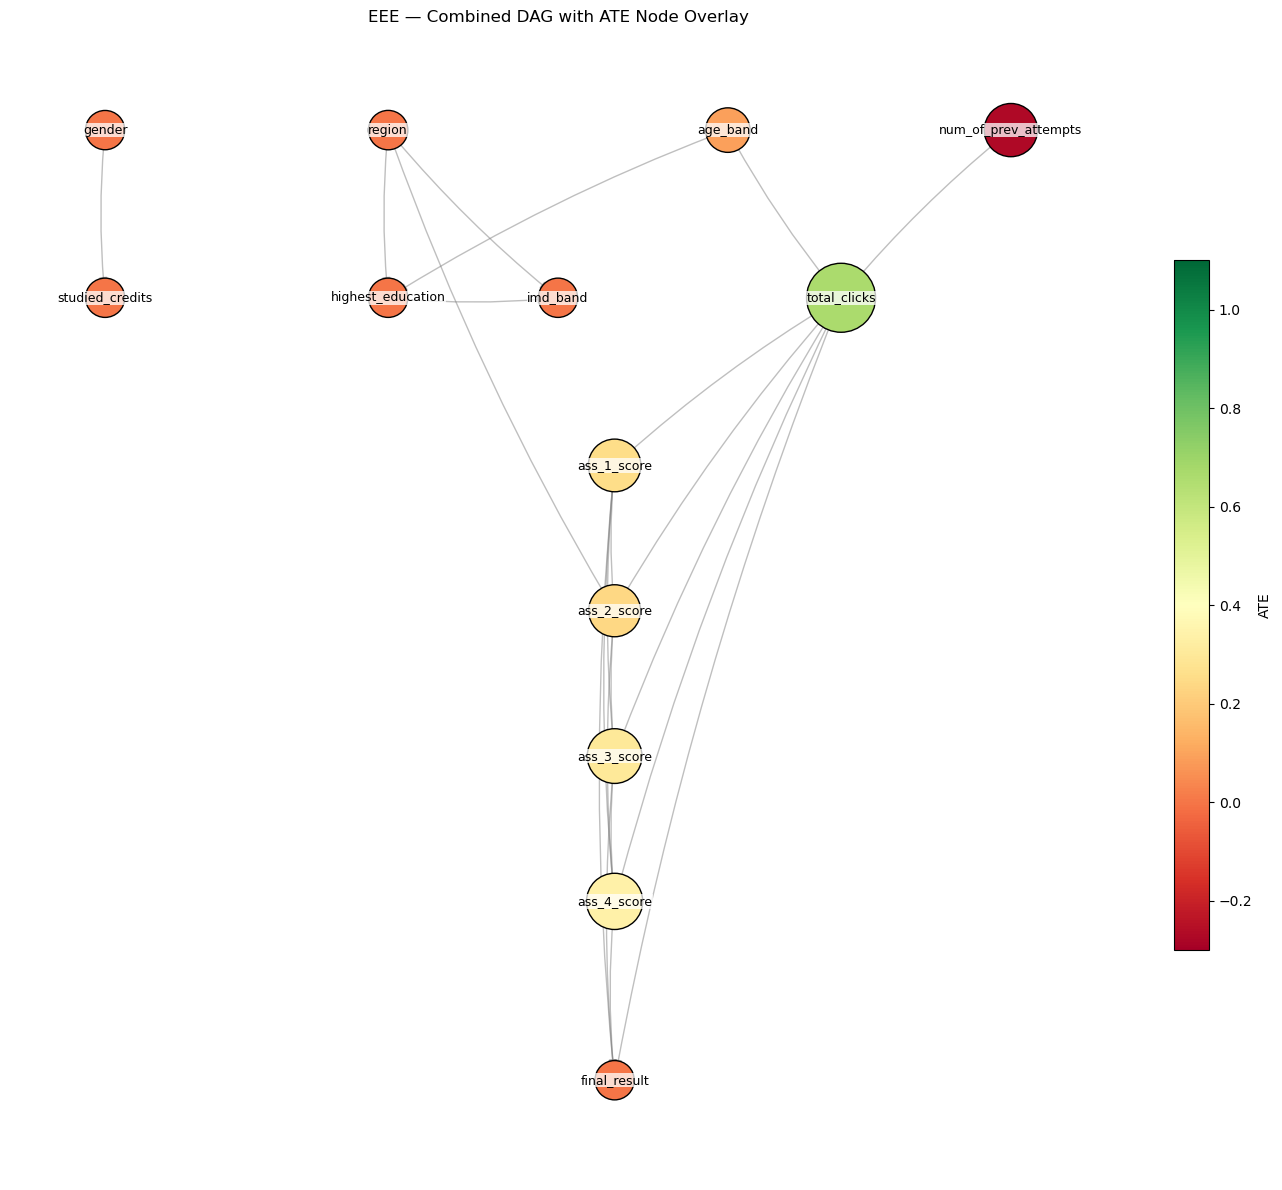

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\EEE\EEE_DAG_with_ATE.png


In [43]:
# Block 13 — DAG with ATE node overlay, manual fixed-position layout

pos = {
    'gender': (0.5, 8),
    'region': (3, 8),
    'age_band': (6, 8),
    'num_of_prev_attempts': (8.5, 8),

    'studied_credits': (0.5, 6.5),
    'highest_education': (3, 6.5),
    'imd_band': (4.5, 6.5),
    'total_clicks': (7, 6.5),

    'ass_1_score': (5, 5),
    'ass_2_score': (5, 3.7),
    'ass_3_score': (5, 2.4),
    'ass_4_score': (5, 1.1),

    'final_result': (5, -0.5),
}

ate_lookup = results_df.set_index('treatment')['ATE'].to_dict()

fig, ax = plt.subplots(figsize=(14, 12))

node_colors, node_sizes = [], []
for node in G.nodes():
    ate_val = ate_lookup.get(node, 0)
    node_colors.append(ate_val)
    node_sizes.append(800 + abs(ate_val) * 2500)

missing_pos = [n for n in G.nodes() if n not in pos]
if missing_pos:
    print("WARNING — missing pos for:", missing_pos)

nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', arrows=True, arrowsize=12, alpha=0.5, connectionstyle='arc3,rad=0.05')
nc = nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                             cmap='RdYlGn', vmin=-0.3, vmax=1.1, edgecolors='black')
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9,
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.5))

cbar = plt.colorbar(nc, ax=ax, shrink=0.6)
cbar.set_label('ATE')

plt.title('EEE — Combined DAG with ATE Node Overlay')
plt.axis('off')
plt.tight_layout()
save_path = os.path.join(output_dir, "EEE_DAG_with_ATE.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")